<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelimabelas/blob/main/PRAKTIKUM_15_2_MG_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REMOTE SENSING: VEGETATION ANALYSIS WITH NDVI


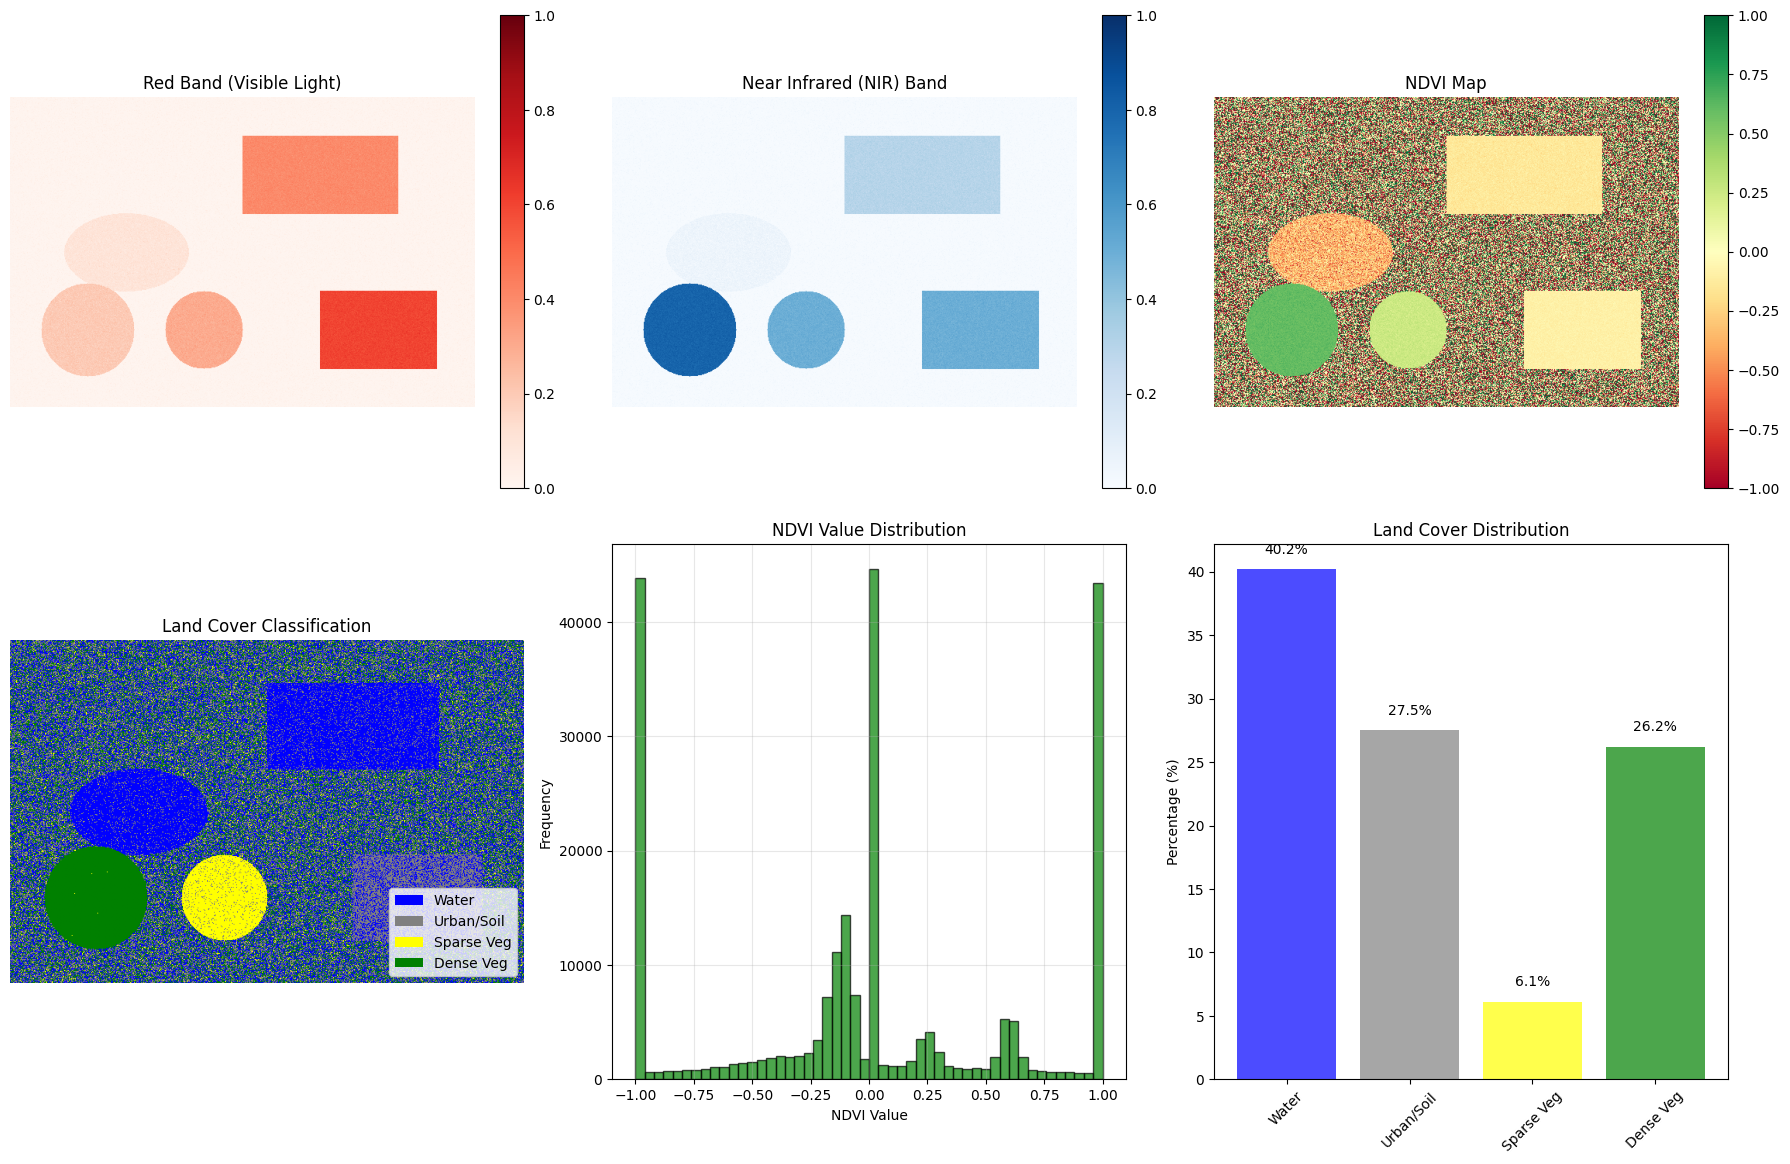

REMOTE SENSING ANALYSIS RESULTS
Average NDVI: -0.002
NDVI Range: -1.000 to 1.000

Land Cover Statistics:
Water          :  96422 pixels ( 40.2%)
Urban/Soil     :  66062 pixels ( 27.5%)
Sparse Veg     :  14662 pixels (  6.1%)
Dense Veg      :  62854 pixels ( 26.2%)

VEGETATION HEALTH ASSESSMENT
-----------------------------------
Healthy vegetation mean NDVI: 0.891
Stressed vegetation mean NDVI: 0.302


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

def praktikum_7_2():
    print("REMOTE SENSING: VEGETATION ANALYSIS WITH NDVI")
    print("=" * 50)

    # Simulate multispectral image data (Red and NIR bands)
    def create_multispectral_data():
        # Create a synthetic landscape
        height, width = 400, 600

        # Red band (visible light)
        red_band = np.zeros((height, width), dtype=np.float32)
        # NIR band (near infrared)
        nir_band = np.zeros((height, width), dtype=np.float32)

        # Add different land cover types
        # 1. Water bodies (low reflectance in both bands)
        cv2.ellipse(red_band, (150, 200), (80, 50), 0, 0, 360, 0.1, -1)
        cv2.ellipse(nir_band, (150, 200), (80, 50), 0, 0, 360, 0.05, -1)

        # 2. Urban areas (moderate reflectance)
        cv2.rectangle(red_band, (300, 50), (500, 150), 0.4, -1)
        cv2.rectangle(nir_band, (300, 50), (500, 150), 0.3, -1)

        # 3. Vegetation areas (low red, high NIR reflectance)
        # Healthy vegetation
        cv2.circle(red_band, (100, 300), 60, 0.2, -1)
        cv2.circle(nir_band, (100, 300), 60, 0.8, -1)

        # Stressed vegetation
        cv2.circle(red_band, (250, 300), 50, 0.3, -1)
        cv2.circle(nir_band, (250, 300), 50, 0.5, -1)

        # 4. Bare soil (high reflectance in both bands)
        cv2.rectangle(red_band, (400, 250), (550, 350), 0.6, -1)
        cv2.rectangle(nir_band, (400, 250), (550, 350), 0.5, -1)

        # Add some noise for realism
        red_band += np.random.normal(0, 0.02, red_band.shape)
        nir_band += np.random.normal(0, 0.02, nir_band.shape)

        # Clip to valid reflectance range [0, 1]
        red_band = np.clip(red_band, 0, 1)
        nir_band = np.clip(nir_band, 0, 1)

        return red_band, nir_band

    # Calculate NDVI
    def calculate_ndvi(red_band, nir_band):
        # NDVI = (NIR - Red) / (NIR + Red)
        numerator = nir_band - red_band
        denominator = nir_band + red_band

        # Avoid division by zero
        denominator = np.where(denominator == 0, 1e-8, denominator)

        ndvi = numerator / denominator
        return ndvi

    # Classify land cover based on NDVI
    def classify_land_cover(ndvi):
        classification = np.zeros(ndvi.shape, dtype=np.uint8)

        # Classification thresholds
        classification[ndvi < -0.1] = 0   # Water
        classification[(ndvi >= -0.1) & (ndvi < 0.2)] = 1  # Urban/Bare soil
        classification[(ndvi >= 0.2) & (ndvi < 0.5)] = 2   # Sparse vegetation
        classification[ndvi >= 0.5] = 3   # Dense vegetation

        return classification

    # Create synthetic multispectral data
    red_band, nir_band = create_multispectral_data()

    # Calculate NDVI
    ndvi = calculate_ndvi(red_band, nir_band)

    # Classify land cover
    land_cover = classify_land_cover(ndvi)

    # Visualize results
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Red band
    im1 = axes[0, 0].imshow(red_band, cmap='Reds', vmin=0, vmax=1)
    axes[0, 0].set_title('Red Band (Visible Light)')
    axes[0, 0].axis('off')
    plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

    # NIR band
    im2 = axes[0, 1].imshow(nir_band, cmap='Blues', vmin=0, vmax=1)
    axes[0, 1].set_title('Near Infrared (NIR) Band')
    axes[0, 1].axis('off')
    plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

    # NDVI
    im3 = axes[0, 2].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[0, 2].set_title('NDVI Map')
    axes[0, 2].axis('off')
    plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

    # Land cover classification
    land_cover_colors = ['blue', 'gray', 'yellow', 'green']
    land_cover_cmap = plt.cm.colors.ListedColormap(land_cover_colors)
    land_cover_labels = ['Water', 'Urban/Soil', 'Sparse Veg', 'Dense Veg']

    im4 = axes[1, 0].imshow(land_cover, cmap=land_cover_cmap, vmin=0, vmax=3)
    axes[1, 0].set_title('Land Cover Classification')
    axes[1, 0].axis('off')

    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=label)
                      for color, label in zip(land_cover_colors, land_cover_labels)]
    axes[1, 0].legend(handles=legend_elements, loc='lower right')

    # NDVI histogram
    axes[1, 1].hist(ndvi.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 1].set_title('NDVI Value Distribution')
    axes[1, 1].set_xlabel('NDVI Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)

    # Land cover statistics
    unique, counts = np.unique(land_cover, return_counts=True)
    total_pixels = land_cover.size
    percentages = [count / total_pixels * 100 for count in counts]

    bars = axes[1, 2].bar(land_cover_labels, percentages,
                         color=land_cover_colors, alpha=0.7)
    axes[1, 2].set_title('Land Cover Distribution')
    axes[1, 2].set_ylabel('Percentage (%)')
    axes[1, 2].tick_params(axis='x', rotation=45)

    # Add percentage labels on bars
    for bar, percentage in zip(bars, percentages):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{percentage:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Quantitative analysis
    print("REMOTE SENSING ANALYSIS RESULTS")
    print("=" * 40)
    print(f"Average NDVI: {np.mean(ndvi):.3f}")
    print(f"NDVI Range: {np.min(ndvi):.3f} to {np.max(ndvi):.3f}")
    print("\nLand Cover Statistics:")
    for label, count, percentage in zip(land_cover_labels, counts, percentages):
        print(f"{label:<15}: {count:>6} pixels ({percentage:5.1f}%)")

    # Advanced analysis: Vegetation health monitoring
    print("\nVEGETATION HEALTH ASSESSMENT")
    print("-" * 35)
    healthy_veg_mask = land_cover == 3
    stressed_veg_mask = land_cover == 2

    if np.any(healthy_veg_mask):
        healthy_ndvi = np.mean(ndvi[healthy_veg_mask])
        print(f"Healthy vegetation mean NDVI: {healthy_ndvi:.3f}")

    if np.any(stressed_veg_mask):
        stressed_ndvi = np.mean(ndvi[stressed_veg_mask])
        print(f"Stressed vegetation mean NDVI: {stressed_ndvi:.3f}")

    return ndvi, land_cover

ndvi_map, land_cover_map = praktikum_7_2()